In [1]:
import numpy as np
from time import sleep


from orchid.context import ExperimentContext
from orchid.procedure import MonitorProcedure, Procedure, Sweep, WriteMode
from orchid.runner import ExperimentRunner
from orchid.plotting import LivePlotter, PlotSpec, EventLineConfig

In [2]:
from eeroqlab.instruments import KoradKA3305P, BlueFors, Vulcan, QDac2Eeroq
from pymeasure.instruments.yokogawa.yokogawa7651 import Yokogawa7651
from pymeasure.instruments.srs.sr830 import SR830
from eeroqlab.instruments import E5071

In [3]:
vulcan  = Vulcan()
yoko    = Yokogawa7651('GPIB0::19::INSTR')
korad   = KoradKA3305P(resourceName='COM9', includeSCPI=False)
bf      = BlueFors("bf_fridge","B://", 1, 2, 3, 4, 5, 6, 1, 2, 3, 5, 6, 7, 8)
lockin  = SR830(name="lockin", adapter='GPIB0::8::INSTR')
qdac    = QDac2Eeroq(name="qdac", address="TCPIP::10.103.204.39::5025::SOCKET", timeout=60)
vna     = E5071(name="E5071C", address="e5071c.eeroq.local")

Connected to: QDevil QDAC-II (serial:86, firmware:13-1.57) in 0.04s


In [29]:
qdac.close()

In [4]:
# gate names to qdac channel mapping
gates = {
    "local_in":    9,         # reservoir 1 of LOCAL ST 
    "local_out":   13,        # reservoir 2 of LOCAL ST 
    "local_gate":  11,        # central gate of LOCAL ST
    "local_top":   15,        # top filament electrode of LOCAL ST
    "remote_gate": 3,         # this is central gate of the REMOTE ST
    "remote_top":  17,        # top filament electrode of REMOTE ST
    "connect":     7,         # this is the channel connecting LOCAL and REMOTE devices
}
qdac.setup_gates(gates)
qdac.snapshot()

╭────────────┬─────────────┬──────────────┬─────────────┬───────────────┬──────────────┬───────────╮
│   local_in │   local_out │   local_gate │   local_top │   remote_gate │   remote_top │   connect │
├────────────┼─────────────┼──────────────┼─────────────┼───────────────┼──────────────┼───────────┤
│        0.6 │         0.6 │          0.9 │        -0.2 │             0 │            0 │         0 │
╰────────────┴─────────────┴──────────────┴─────────────┴───────────────┴──────────────┴───────────╯


In [5]:
ctx = ExperimentContext(
    data_root="./data",
    metadata={
        "sample": "chip_A1",
        "operator": "Niyaz",
        "fridge": "BlueFors_1",
        "cooldown": 42,
    },
)

In [6]:
ctx.add_instrument("lockin", lockin, backend="pymeasure")
ctx.add_instrument("qdac", qdac, backend="qcodes")
ctx.add_instrument("vna", vna, backend="custom")
ctx.add_instrument("vulcan", vulcan, backend="custom")
ctx.add_instrument("bluefors", bf, backend="qcodes")

InstrumentAdapter('bluefors', backend='qcodes')

In [7]:
ctx.add_parameter("T6", get_func=lambda: bf.get_temperature(6), unit="K")
ctx.add_parameter("Vch", get_func=lambda: qdac.local_gate.dc_constant_V(), set_func=lambda x: qdac.local_gate.ramp_V(x), unit="V")

def set_Vr(x):
    qdac.local_in.ramp_V(x)
    qdac.local_out.ramp_V(x)

ctx.add_parameter("Vr", get_func=qdac.local_in.dc_constant_V, set_func=set_Vr, unit="V")
ctx.add_parameter("tau_flash", get_func=lambda: vulcan.get_duration(), set_func=lambda x: vulcan.set_duration(x), unit="s")
ctx.add_parameter("fac", instrument="lockin", attr="frequency", unit="Hz")
ctx.add_parameter("Vac", instrument="lockin", attr="sine_voltage", unit="Vrms")

Parameter('Vac', sine_voltage, unit='Vrms')

In [9]:
ctx["fac"]

35310.0

In [10]:
ctx.snapshot()

Name       Type           Value  Unit
---------  ------  ------------  ------
T6         param       0.021721  K
Vch        param       0.9       V
Vr         param       0.6       V
tau_flash  param     100         s
fac        param   35310         Hz
Vac        param       1         Vrms


In [12]:
def Vmag():
    return np.sqrt(lockin.x**2 + lockin.y**2)

In [13]:
ctx.add_readout("Vx", kind="scalar", get_func=lambda: lockin.x, unit="V")
ctx.add_readout("Vy", kind="scalar", get_func=lambda: lockin.y, unit="V")
ctx.add_readout("S21", kind="image", shape=(1601,3),
    get_func=vna.take_one_averaged_trace,
    unit=["Hz","dB","deg"],
    contains=["f","mag","phase"],)
ctx.add_readout("Vmag", kind="scalar", get_func=Vmag, unit="V")

Readout('Vmag', scalar, shape=None)

In [14]:
ctx

ExperimentContext(5 instruments, 6 parameters, 4 readouts)

### **1D scan**

In [16]:
def hook_init_exp():
    ctx["Vch"] = 0
    sleep(2)

In [17]:
proc1 = Procedure(
    name="Vch_sweep",
    context=ctx,
    sweeps=[
        Sweep("Vch", np.linspace(0, 0.9, 51)),
    ],
    readouts=["Vx", "Vy", 'Vmag'],
    settle_time=0.9,          # 10ms settle after each set
    tags=["transport", "1d"],
    metadata={"field": "0T"},
    write_mode=WriteMode.SWEEPWISE,
    before_experiment=hook_init_exp
)

In [18]:
plotter = LivePlotter([
    PlotSpec(x="Vch", y="Vx", update_every="point"),
    PlotSpec(x="Vx", y="Vy", update_every="point"),
    PlotSpec(x="Vch", y="Vmag", update_every="point")
    ]
)

In [19]:
runner = ExperimentRunner()

In [20]:
ctx.snapshot()

Name       Type    Value                  Unit
---------  ------  ---------------------  -------------------
T6         param   0.021781               K
Vch        param   0.9                    V
Vr         param   0.6                    V
tau_flash  param   100                    s
fac        param   35310.0                Hz
Vac        param   1.0                    Vrms
Vx         scalar  0.000243546            V
Vy         scalar  8.8573e-05             V
S21        image   [[...]]                ['Hz', 'dB', 'deg']
Vmag       scalar  0.0002575948343141997  V


In [21]:
runner.run(proc1, plotter=plotter)

Live plot server started at http://localhost:8050


Vch_sweep: 100%|██████████| 51/51 [00:55<00:00,  1.09s/pt]

Live plot server stopped.
Experiment 'Vch_sweep' completed. Data saved to: data\0002


### **2D scan**

In [35]:
def hook_init_sweep(index):
    ctx["Vch"] = 0.
    sleep(2)

In [36]:
ctx.snapshot()

Name       Type    Value                  Unit
---------  ------  ---------------------  -------------------
T6         param   0.743944               K
Vch        param   0.0                    V
Vr         param   0.42                   V
tau_flash  param   100                    s
fac        param   35310.0                Hz
Vac        param   1.0                    Vrms
Vx         scalar  1.78815e-07            V
Vy         scalar  7.3314e-06             V
S21        image   [[...]]                ['Hz', 'dB', 'deg']
Vmag       scalar  4.092398839425234e-06  V


In [22]:
vulcan.flash()

In [37]:
proc2 = Procedure(
    name="Vch_sweep",
    context=ctx,
    sweeps=[
        Sweep("Vr", np.linspace(0.5, 0.6, 11)),
        Sweep("Vch", np.linspace(0, 0.6, 21)),
    ],
    readouts=["Vx", "Vy"],
    settle_time=0.6,          # 10ms settle after each set
    tags=["transport", "1d"],
    metadata={"field": "0T"},
    write_mode=WriteMode.SWEEPWISE,
    before_sweep=hook_init_sweep
)

In [38]:
plotter = LivePlotter([
    PlotSpec(x="Vch", y="Vx", update_every="point"),
    PlotSpec(x="Vch", y="Vy", update_every="point"),
    PlotSpec(x="Vch", y="Vr", z='Vx', update_every="point")
    ]
)

In [39]:
runner = ExperimentRunner()
runner.run(proc2, plotter=plotter)

Live plot server started at http://localhost:8050


Vch_sweep: 100%|██████████| 231/231 [03:17<00:00,  1.17pt/s]

Live plot server stopped.
Experiment 'Vch_sweep' completed. Data saved to: data\0004


In [ ]:
plotter.is_running

Live plot server stopped.


In [40]:
import zarr
import matplotlib.pyplot as plt

['Vx', 'Vy', '_time']


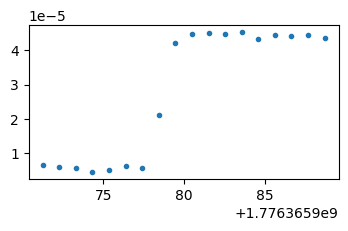

In [ ]:
# Open vault
z = zarr.open("./example_data/0010/vault.zarr", mode="r")

# List arrays
print(list(z.keys()))    # ['Vgt', 'lockin_X']

# Read arrays (standard NumPy indexing)
# vgt = z["Vch"][:]          # control values, shape (101,)
vgt = z["_time"][:]          # control values, shape (101,)
signal = z["Vy"][:]  # measured data, shape (101,)
plt.figure(figsize=(4,2))
plt.plot(vgt, signal, ".")
plt.show()

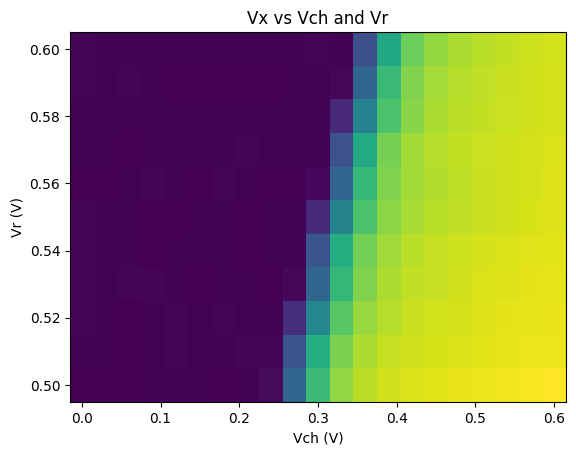

In [42]:
# For 2D: shape is (outer_len, inner_len)
z = zarr.open("./data/0004/vault.zarr", mode="r")
data_2d = z["Vx"][:]  # shape (50, 101)
Vch = z["Vch"][:]  # shape (101)
Vr = z["Vr"][:]  # shape (50)

plt.pcolormesh(Vch, Vr, data_2d)
plt.xlabel("Vch (V)")
plt.ylabel("Vr (V)")
plt.title("Vx vs Vch and Vr")
plt.show()


### **Time Series**

In [22]:
monitor = MonitorProcedure(
    name="stability_check",
    context=ctx,
    readouts=["Vx","Vy"],
    interval=1.0,       # 1 second between reads
    duration=None,     # 1 hour
    tags=["stability"],
)
runner = ExperimentRunner()

event_line=EventLineConfig(
    color="rgba(0,150,255,0.8)",
    width=2,
    dash="dot",
    font_size=15,
)
plotter = LivePlotter([PlotSpec(x="_time", y="Vx")], height = 700, width = 1400, open_browser=True, event_line=event_line)

In [28]:
runner.is_monitoring

False

In [ ]:
runner.run_monitor(monitor, plotter=plotter, background=True)

Monitor 'stability_check' running in background. Use runner.stop_monitor() to stop.


Live plot server started at http://localhost:8050
Monitor 'stability_check' completed. Data saved to: data\0003


In [25]:
ctx["Vch"] = 0.4

In [27]:
ctx["Vr"] = 0.5

In [28]:
runner.stop_monitor()

Monitor stopped. Data saved to: data\0003


WindowsPath('data/0003')

In [34]:
plotter.is_running

False